In [1]:
# @title
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 96% 2.20G/2.29G [00:34<00:04, 19.7MB/s]
100% 2.29G/2.29G [00:34<00:00, 71.2MB/s]


In [70]:
import zipfile
zip_ref = zipfile.ZipFile('/content/chest-xray-pneumonia.zip' , 'r')
zip_ref.extractall('/content')

In [4]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Conv2D, Flatten , MaxPooling2D , Dropout , BatchNormalization
from tensorflow.keras.applications.vgg16 import VGG16

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/chest_xray/train',
    labels = 'inferred',
    label_mode = 'binary',
    batch_size = 32,
    image_size = (256 , 256)
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/chest_xray/test',
    labels = 'inferred',
    label_mode = 'binary',
    batch_size = 32,
    image_size = (256 , 256)
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


# Function To normalize

In [6]:
def norm(image , label):
  image = tf.cast(image/255. , tf.float32)
  return image , label


train_ds = train_ds.map(norm)
validation_ds = validation_ds.map(norm)

In [ ]:
model = Sequential()
model.add(Conv2D(64 , kernel_size=(3,3) , padding='same' , activation='relu' , input_shape = (256 , 256 , 3)))
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'same'))

model.add(Conv2D(128 , kernel_size=(3,3) , padding='same' , activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'same'))

model.add(Conv2D(256 , kernel_size=(3,3) , padding='same' , activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'same'))

model.add(Flatten())
model.add(Dense(256 , activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(128 , activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1 , activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │    67,109,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,512,961 (257.54 MB)

 Trainable params: 67,512,961 (257.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds , epochs=10 , validation_data=validation_ds)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 220ms/step - accuracy: 0.7454 - loss: 0.8371 - val_accuracy: 0.7692 - val_loss: 0.6890
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 237ms/step - accuracy: 0.9110 - loss: 0.2094 - val_accuracy: 0.7404 - val_loss: 0.6694
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 212ms/step - accuracy: 0.9510 - loss: 0.1282 - val_accuracy: 0.7532 - val_loss: 1.3134
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.9692 - loss: 0.0823 - val_accuracy: 0.7564 - val_loss: 1.0345
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 229ms/step - accuracy: 0.9717 - loss: 0.0842 - val_accuracy: 0.7163 - val_loss: 2.3365
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 216ms/step - accuracy: 0.9828 - loss: 0.0488 - val_accuracy: 0.7115 - val_loss: 2.5492
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 217ms/step - accuracy: 0.9836 - loss: 0.0449 - val_accuracy: 0.7388 - val_loss: 2.1994
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 217ms/step - accuracy: 0.9880 - loss: 0

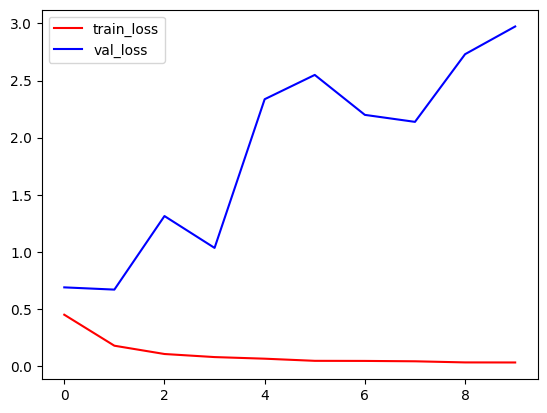

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'] , color = 'red' , label = 'train_loss')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'val_loss')
plt.legend()
plt.show()

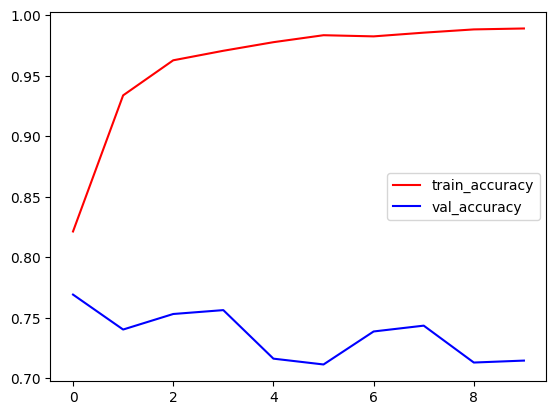

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train_accuracy')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'val_accuracy')
plt.legend()
plt.show()

# Overfiitting


# Using transfer learning (VGGNET) model `Feature Extraction`

In [ ]:
conv_base = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(256,256,3)
  )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()
model.add(conv_base)

model.add(Flatten())
model.add(Dense(256 , activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(128 , activation = 'relu'))
model.add(Dropout(0.6))
model.add(Dense(1 , activation = 'sigmoid'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,103,809 (88.13 MB)

 Trainable params: 23,103,809 (88.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.trainable = False

In [ ]:
model.compile(optimizer='adam' , loss = 'binary_crossentropy' , metrics=['accuracy'])

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator , img_to_array , array_to_img , load_img

In [8]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    shear_range = 0.2 ,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [9]:
train_genrator = train_datagen.flow_from_directory(
    '/content/chest_xray/train',
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary'
)

test_generator = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
history = model.fit(train_genrator , epochs=10, validation_data=test_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 162s 864ms/step - accuracy: 0.8614 - loss: 0.6904 - val_accuracy: 0.9375 - val_loss: 0.2001
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 796ms/step - accuracy: 0.9544 - loss: 0.1175 - val_accuracy: 0.9247 - val_loss: 0.2136
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 803ms/step - accuracy: 0.9515 - loss: 0.1288 - val_accuracy: 0.9167 - val_loss: 0.2588
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 792ms/step - accuracy: 0.9601 - loss: 0.0993 - val_accuracy: 0.9071 - val_loss: 0.2353
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 791ms/step - accuracy: 0.9619 - loss: 0.1043 - val_accuracy: 0.8798 - val_loss: 0.4979
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 779ms/step - accuracy: 0.9615 - loss: 0.1064 - val_accuracy: 0.9151 - val_loss: 0.2596
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 776ms/step - accuracy: 0.9759 - loss: 0.0657 - val_accuracy: 0.8878 - val_loss: 0.3728
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 776ms/step - accuracy: 0.9677 -

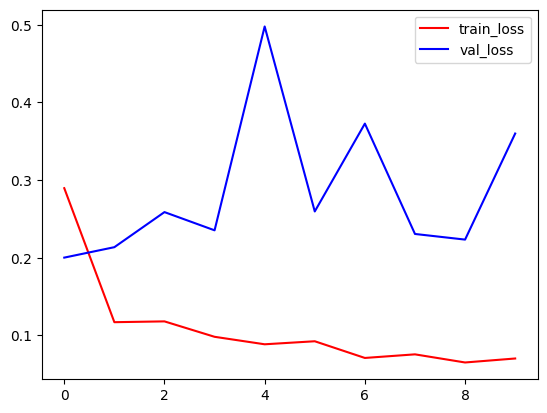

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'] , color = 'red' , label = 'train_loss')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'val_loss')
plt.legend()
plt.show()

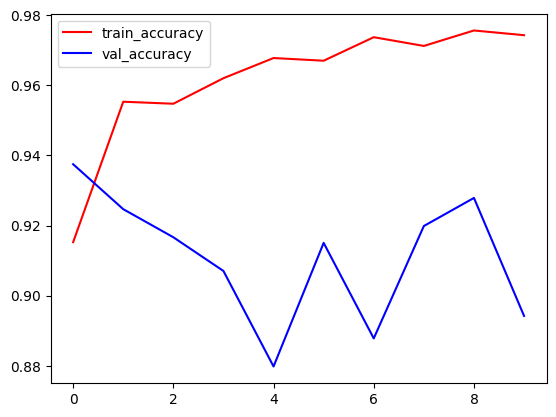

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train_accuracy')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'val_accuracy')
plt.legend()
plt.show()

# Using transfer learning (VGGNET) model `Fine Tuning`

In [10]:
conv_base = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(256,256,3)
  )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [11]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow.keras.layers import Input

In [27]:
inputs = Input(shape=(256, 256, 3))

In [28]:
conv_base.trainable = True  # First, mark the whole base as trainable

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True

    # Freezes layers before block5, unfreezes block5 and after
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

In [29]:
for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [30]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [54]:
# 1. Get output from VGG16
vgg_output = conv_base(inputs, training=False)

In [55]:
# SAFETY CHECK: Fixes the 'list object has no attribute shape' error
if isinstance(vgg_output, list):
  x = vgg_output[0]

In [56]:
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation

In [57]:
# 2. FLATTEN IT
# We take 'vgg_output' -> Flatten it -> Save as 'flat'
flat = Flatten()(vgg_output)

# 3. Dense Layers
# Now we pass 'flat' into the first Dense layer
layer1 = Dense(256, use_bias=False)(flat)
layer1 = BatchNormalization()(layer1)
layer1 = Activation('relu')(layer1)
layer1 = Dropout(0.5)(layer1)

# Pass 'layer1' into the next
layer2 = Dense(128, use_bias=False)(layer1)
layer2 = BatchNormalization()(layer2)
layer2 = Activation('relu')(layer2)
layer2 = Dropout(0.5)(layer2)

layer3 = Dense(64, use_bias=False)(layer2)
layer3 = BatchNormalization()(layer3)
layer3 = Activation('relu')(layer3)
layer3 = Dropout(0.5)(layer3)

# 4. Output
outputs = Dense(1, activation='sigmoid')(layer3)

In [58]:
from keras.models import Model

In [59]:
model = Model(inputs=inputs, outputs=outputs)

In [60]:
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │     8,388,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,146,113 (88.30 MB)

 Trainable params: 15,509,953 (59.17 MB)

 Non-trainable params: 7,636,160 (29.13 MB)

In [61]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

In [62]:
model.compile(optimizer= optimizer, loss = 'binary_crossentropy' , metrics=['accuracy'])

In [63]:
history = model.fit(train_genrator , epochs = 10, validation_data = test_generator)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 831ms/step - accuracy: 0.7089 - loss: 0.5860 - val_accuracy: 0.8798 - val_loss: 0.4252
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 814ms/step - accuracy: 0.8263 - loss: 0.4096 - val_accuracy: 0.8910 - val_loss: 0.3573
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 809ms/step - accuracy: 0.8628 - loss: 0.3592 - val_accuracy: 0.9054 - val_loss: 0.3476
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 791ms/step - accuracy: 0.8685 - loss: 0.3467 - val_accuracy: 0.9103 - val_loss: 0.3086
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 822ms/step - accuracy: 0.8903 - loss: 0.3153 - val_accuracy: 0.9103 - val_loss: 0.3153
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 797ms/step - accuracy: 0.8983 - loss: 0.3074 - val_accuracy: 0.9167 - val_loss: 0.3090
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 793ms/step - accuracy: 0.9128 - loss: 0.2831 - val_accuracy: 0.9247 - val_loss: 0.2833
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 797ms/step - accuracy: 0.9166 -

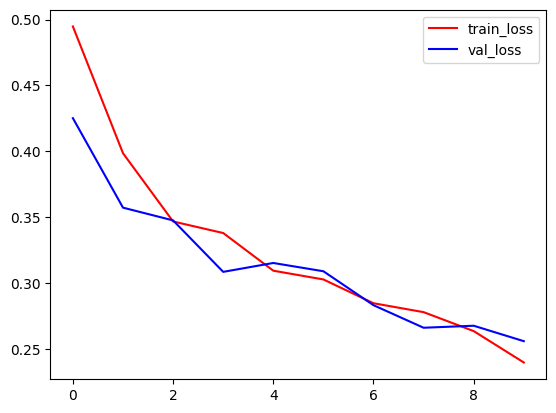

In [64]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'] , color = 'red' , label = 'train_loss')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'val_loss')
plt.legend()
plt.show()

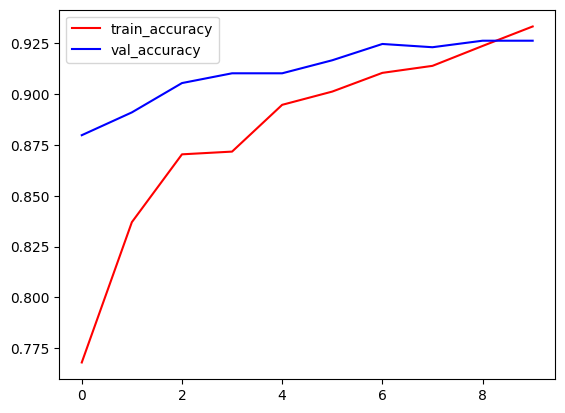

In [65]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train_accuracy')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'val_accuracy')
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step


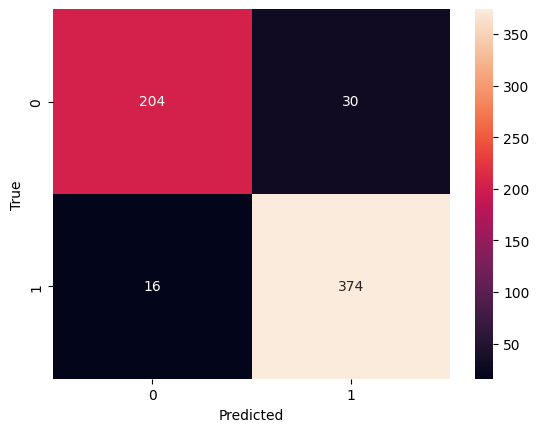

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       234
           1       0.93      0.96      0.94       390

    accuracy                           0.93       624
   macro avg       0.93      0.92      0.92       624
weighted avg       0.93      0.93      0.93       624



In [68]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
# Note: Ensure test_generator is reset or shuffle=False
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
y_true = test_generator.classes

# Create the matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred))

In [69]:
model.save('chest_xray_vgg16_finetuned.h5')